### **SET UP ENVIRONMENT**

In [ ]:
!pip install implicit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import coo_matrix
from implicit.als import AlternatingLeastSquares

### **Load Dataset**

In [ ]:
rating = pd.read_csv("rating.csv")
movie = pd.read_csv("movie.csv")

rating.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [ ]:
movie.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
rating.info()

print("Jumlah user:", rating['userId'].nunique())
print("Jumlah movie:", rating['movieId'].nunique())
print("Jumlah rating:", len(rating))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10005980 entries, 0 to 10005979
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 305.4+ MB
Jumlah user: 69199
Jumlah movie: 23304
Jumlah rating: 10005980


### **EDA**

In [ ]:
plt.rcParams.update({
    "figure.figsize": (9,5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3
})

Overview Dataset

Tujuan: menunjukkan pemahaman struktur data & skala

In [ ]:
rating.describe()

,userId,movieId,rating
count,1.000598e+07,1.000598e+07,1.000598e+07
mean,3.439173e+04,9.111991e+03,3.525608e+00
std,2.002583e+04,1.988191e+04,1.051797e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,1.693800e+04,9.030000e+02,3.000000e+00
50%,3.440300e+04,2.174000e+03,3.500000e+00
75%,5.177000e+04,4.821000e+03,4.000000e+00
max,6.919900e+04,1.312600e+05,5.000000e+00


Distribusi Rating

ALS sensitif terhadap distribusi rating (bias user & item)

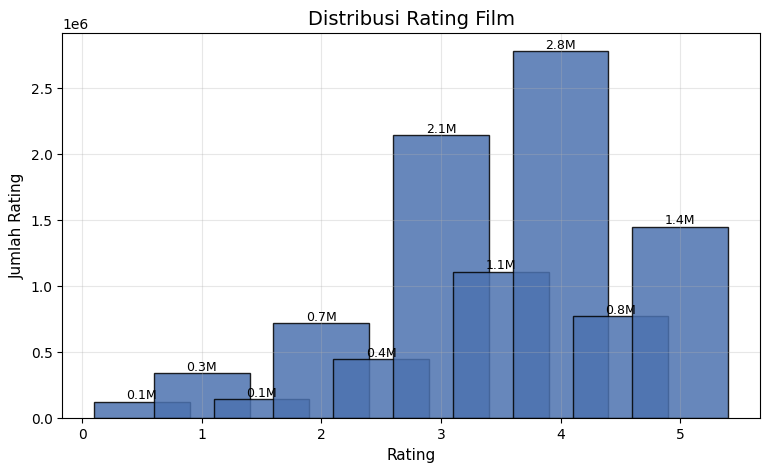

In [ ]:
rating_counts = rating['rating'].value_counts().sort_index()

plt.figure(figsize=(9,5))
bars = plt.bar(
    rating_counts.index,
    rating_counts.values,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.85
)

plt.title("Distribusi Rating Film")
plt.xlabel("Rating")
plt.ylabel("Jumlah Rating")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1_000_000:.1f}M",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

Aktivitas User (User Behavior)

Tujuan: identifikasi heavy vs cold user

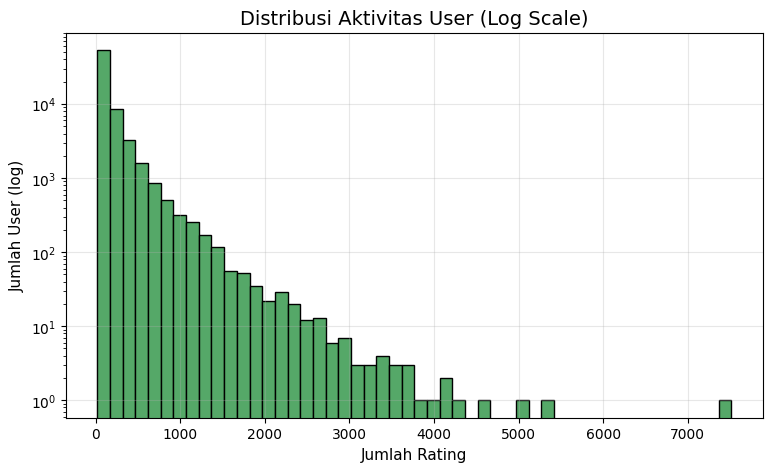

In [ ]:
user_activity = rating.groupby('userId').size()

plt.hist(
    user_activity,
    bins=50,
    color="#55A868",
    edgecolor="black",
    log=True
)

plt.title("Distribusi Aktivitas User (Log Scale)")
plt.xlabel("Jumlah Rating")
plt.ylabel("Jumlah User (log)")
plt.show()

Popularitas Movie

Tujuan: melihat item populer vs long-tail

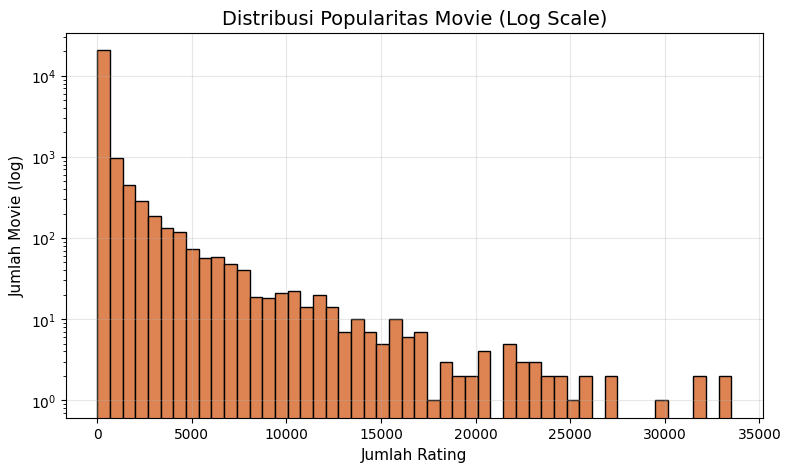

In [ ]:
movie_popularity = rating.groupby('movieId').size()

plt.hist(
    movie_popularity,
    bins=50,
    color="#DD8452",
    edgecolor="black",
    log=True
)

plt.title("Distribusi Popularitas Movie (Log Scale)")
plt.xlabel("Jumlah Rating")
plt.ylabel("Jumlah Movie (log)")
plt.show()

Sparsity Matrix

In [ ]:
num_users = rating['userId'].nunique()
num_movies = rating['movieId'].nunique()
num_ratings = len(rating)

sparsity = 1 - (num_ratings / (num_users * num_movies))
sparsity

0.9937951778124025

Join dengan Movie Metadata

In [ ]:
rating_movie = rating.merge(movie, on='movieId', how='left')
rating_movie[['title', 'rating']].head()

,title,rating
0,Jumanji (1995),3.5
1,"City of Lost Children, The (Cité des enfants p...",3.5
2,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),3.5
3,Seven (a.k.a. Se7en) (1995),3.5
4,"Usual Suspects, The (1995)",3.5


Rata-rata Rating per Movie (Quality vs Popularity)

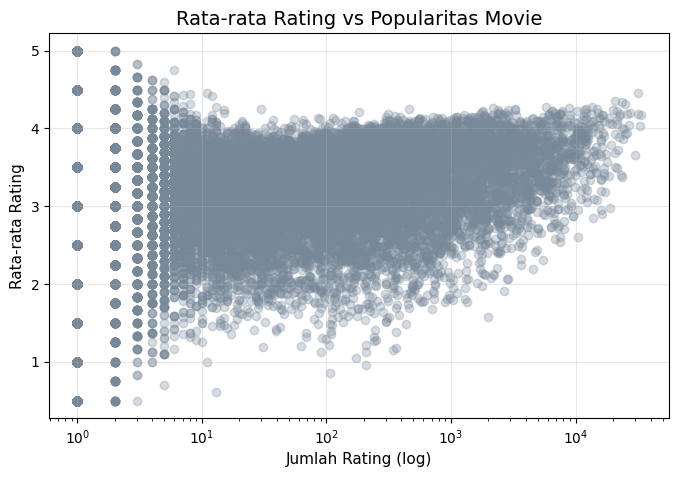

In [ ]:
movie_stats = rating.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    count_rating=('rating', 'count')
)

plt.figure(figsize=(8,5))
plt.scatter(
    movie_stats['count_rating'],
    movie_stats['avg_rating'],
    alpha=0.3,
    color="#778899"
)

plt.xscale('log')
plt.xlabel("Jumlah Rating (log)")
plt.ylabel("Rata-rata Rating")
plt.title("Rata-rata Rating vs Popularitas Movie")
plt.show()

Rata-rata Rating per User (User Bias)

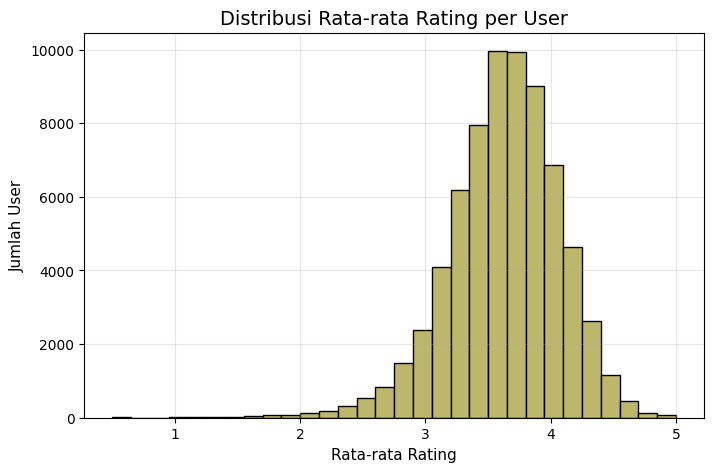

In [ ]:
user_avg_rating = rating.groupby('userId')['rating'].mean()

plt.figure(figsize=(8,5))
plt.hist(
    user_avg_rating,
    bins=30,
    color="#BDB76B",
    edgecolor="black"
)

plt.title("Distribusi Rata-rata Rating per User")
plt.xlabel("Rata-rata Rating")
plt.ylabel("Jumlah User")
plt.show()

Movie Paling Populer (Top-10)

In [ ]:
top_movies = rating.groupby('movieId').size().sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index(name='jumlah_rating')

top_movies.merge(movie, on='movieId', how='left')

,movieId,jumlah_rating,title,genres
0,296,33522,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,356,33054,Forrest Gump (1994),Comedy|Drama|Romance|War
2,318,31639,"Shawshank Redemption, The (1994)",Crime|Drama
3,593,31553,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,480,29923,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
5,260,27254,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,110,26820,Braveheart (1995),Action|Drama|War
7,589,26095,Terminator 2: Judgment Day (1991),Action|Sci-Fi
8,2571,25668,"Matrix, The (1999)",Action|Sci-Fi|Thriller
9,527,25114,Schindler's List (1993),Drama|War


Rating Over Time

In [ ]:
rating['timestamp'] = pd.to_datetime(
    rating['timestamp'],
    errors='coerce',
    format='mixed'
)

rating = rating.dropna(subset=['timestamp']).copy()

rating['year'] = rating['timestamp'].dt.year

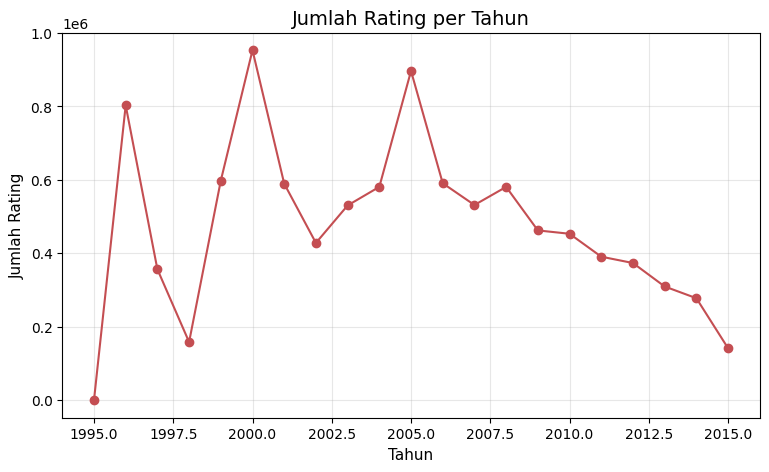

In [ ]:
yearly_rating = rating.groupby('year').size()

plt.figure(figsize=(9,5))
plt.plot(
    yearly_rating.index,
    yearly_rating.values,
    marker='o',
    color="#C44E52"
)

plt.title("Jumlah Rating per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Rating")
plt.show()


### **Data Preparation**

Copy Dataset Mentah

In [ ]:
rating_prep = rating.copy()

Cek Missing dan Duplicate

In [ ]:
rating_prep.isnull().sum()
rating_prep.duplicated().sum()

np.int64(0)

Hitung Aktivitas User & Movie

In [ ]:
user_activity = rating_prep.groupby('userId').size()
movie_activity = rating_prep.groupby('movieId').size()

Filtering Low-Activity User & Movie

In [ ]:
rating_filtered = rating_prep[
    rating_prep['userId'].isin(user_activity[user_activity >= 5].index) &
    rating_prep['movieId'].isin(movie_activity[movie_activity >= 5].index)
]

print("Jumlah rating awal:", len(rating))
print("Jumlah rating setelah filtering:", len(rating_filtered))


Jumlah rating awal: 10005979
Jumlah rating setelah filtering: 9991168


Cek Sparsity Setelah Filtering

In [ ]:
num_users = rating_filtered['userId'].nunique()
num_movies = rating_filtered['movieId'].nunique()
num_ratings = len(rating_filtered)

sparsity_filtered = 1 - (num_ratings / (num_users * num_movies))
sparsity_filtered


0.9906632742547983

### **Feature Engineering**

Encode User & Movie ke Index Numerik

In [ ]:
rating_filtered['user_code'] = rating_filtered['userId'].astype('category').cat.codes
rating_filtered['movie_code'] = rating_filtered['movieId'].astype('category').cat.codes

/tmp/ipython-input-2094826434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_filtered['user_code'] = rating_filtered['userId'].astype('category').cat.codes
/tmp/ipython-input-2094826434.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_filtered['movie_code'] = rating_filtered['movieId'].astype('category').cat.codes


Mapping Index ke ID Asli

In [ ]:
user_map = dict(enumerate(
    rating_filtered['userId'].astype('category').cat.categories
))

movie_map = dict(enumerate(
    rating_filtered['movieId'].astype('category').cat.categories
))


Rating Normalization

In [ ]:
rating_filtered['rating_norm'] = (
    rating_filtered['rating'] - rating_filtered['rating'].mean()
)

/tmp/ipython-input-682307163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_filtered['rating_norm'] = (


Build User (Item Interaction Matrix)

In [ ]:
# from scipy.sparse import coo_matrix

# interaction_matrix = coo_matrix(
#     (
#         rating_filtered['rating'],
#         (rating_filtered['user_code'], rating_filtered['movie_code'])
#     )
# )

Sanity Check Matrix

In [ ]:
# interaction_matrix.shape

### **Training Model Utama dan Model Pembanding**

ALS

In [ ]:
from scipy.sparse import csr_matrix
import numpy as np

# encode user & movie
u_cat = rating_filtered['userId'].astype('category')
m_cat = rating_filtered['movieId'].astype('category')

rating_filtered['user_code'] = u_cat.cat.codes
rating_filtered['movie_code'] = m_cat.cat.codes

# mapping
user_map = dict(enumerate(u_cat.cat.categories))
movie_map = dict(enumerate(m_cat.cat.categories))

user_id_to_code = {v: k for k, v in user_map.items()}


/tmp/ipython-input-3370661660.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_filtered['user_code'] = u_cat.cat.codes
/tmp/ipython-input-3370661660.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_filtered['movie_code'] = m_cat.cat.codes


In [ ]:
ui = csr_matrix(
    (
        rating_filtered['rating'].astype(np.float32),
        (rating_filtered['user_code'], rating_filtered['movie_code'])
    )
)

iu = ui.T  # ITEM x USER (WAJIB buat implicit ALS)

print("Matrix shape:", ui.shape)
print("Non-zero interactions:", ui.nnz)


Matrix shape: (69199, 15464)
Non-zero interactions: 9991168


Training Model ALS

In [ ]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.05,
    iterations=20,
    random_state=42
)

als_model.fit(iu)

print("ALS training selesai ✅")


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.17257404327392578 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

ALS training selesai ✅


Top-N Recommendation (ALS)

In [ ]:
movie_id_to_title = dict(zip(movie['movieId'], movie['title']))

def recommend_for_user(user_id_asli, N=10):
    if user_id_asli not in user_id_to_code:
        return "User tidak tersedia setelah filtering"

    ucode = user_id_to_code[user_id_asli]

    ids, scores = als_model.recommend(
        userid=ucode,
        user_items=ui[ucode],
        N=N,
        filter_already_liked_items=True
    )

    movie_ids = []
    titles = []
    final_scores = []

    for i, s in zip(ids, scores):
        i = int(i)
        if i in movie_map:
            mid = movie_map[i]
            movie_ids.append(mid)
            titles.append(movie_id_to_title.get(mid, "-"))
            final_scores.append(s)

    return pd.DataFrame({
        "Rank": range(1, len(movie_ids)+1),
        "Movie": titles,
        "Score": final_scores
    })


Test ALS

In [ ]:
recommend_for_user(user_map[0], 10)


,Rank,Movie,Score
0,1,You Kill Me (2007),1.648432
1,2,"Friends of Eddie Coyle, The (1973)",1.508780


**MODEL PEMBANDING – MOST POPULAR RECOMMENDER**

In [ ]:
popular_movies = (
    rating_filtered
    .groupby('movie_code')
    .size()
    .sort_values(ascending=False)
)

TOP_K = 10
most_popular_codes = popular_movies.head(TOP_K).index.tolist()


In [ ]:
def recommend_most_popular(N=10):
    codes = most_popular_codes[:N]
    titles = [
        movie_id_to_title.get(movie_map[c], "-")
        for c in codes
    ]

    return pd.DataFrame({
        "Rank": range(1, len(titles)+1),
        "Movie": titles
    })


In [ ]:
recommend_most_popular(10)

,Rank,Movie
0,1,Pulp Fiction (1994)
1,2,Forrest Gump (1994)
2,3,"Shawshank Redemption, The (1994)"
3,4,"Silence of the Lambs, The (1991)"
4,5,Jurassic Park (1993)
5,6,Star Wars: Episode IV - A New Hope (1977)
6,7,Braveheart (1995)
7,8,Terminator 2: Judgment Day (1991)
8,9,"Matrix, The (1999)"
9,10,Schindler's List (1993)


### **Evaluasi Model dan Perbandingan User**

Train–Test Split per User

In [ ]:
def split_train_test_by_user(df, test_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train, test = [], []

    for uid, g in df.groupby('user_code'):
        idx = g.index.to_numpy()
        if len(idx) <= 1:
            train.append(g)
            continue

        n_test = max(1, int(len(idx) * test_ratio))
        test_idx = rng.choice(idx, size=n_test, replace=False)
        train_idx = np.setdiff1d(idx, test_idx)

        train.append(df.loc[train_idx])
        test.append(df.loc[test_idx])

    return pd.concat(train), pd.concat(test)

train_df, test_df = split_train_test_by_user(rating_filtered)


Build Train & Test Matrix

In [ ]:
train_ui = csr_matrix(
    (
        train_df['rating'].astype(np.float32),
        (train_df['user_code'], train_df['movie_code'])
    ),
    shape=ui.shape
)

test_ui = csr_matrix(
    (
        test_df['rating'].astype(np.float32),
        (test_df['user_code'], test_df['movie_code'])
    ),
    shape=ui.shape
)


Re-Train ALS (pakai train set)

In [ ]:
als_model.fit(train_ui.T)

/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.13581609725952148 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
def precision_recall_at_k(model, train_ui, test_ui, K=10, max_users=2000):
    users = np.where(test_ui.getnnz(axis=1) > 0)[0][:max_users]

    precisions, recalls = [], []

    for u in users:
        true_items = set(test_ui[u].indices)

        rec_items, _ = model.recommend(
            userid=u,
            user_items=train_ui[u],
            N=K,
            filter_already_liked_items=True
        )

        hit = len(set(rec_items) & true_items)
        precisions.append(hit / K)
        recalls.append(hit / len(true_items))

    return {
        f"Precision@{K}": np.mean(precisions),
        f"Recall@{K}": np.mean(recalls),
        "Users_evaluated": len(users)
    }

metrics_als = precision_recall_at_k(als_model, train_ui, test_ui, K=10)
metrics_als


{'Precision@10': np.float64(0.00045000000000000004),
 'Recall@10': np.float64(0.00012912171312839745),
 'Users_evaluated': 2000}

In [ ]:
# Popularitas movie dari TRAIN data
popular_movies_train = (
    train_df
    .groupby('movie_code')
    .size()
    .sort_values(ascending=False)
)

TOP_K = 10
most_popular_codes = popular_movies_train.head(TOP_K).index.tolist()


In [ ]:
def recommend_most_popular_codes(N=10):
    return most_popular_codes[:N]

In [ ]:
def precision_recall_at_k_most_popular(
    popular_codes, test_ui, K=10, max_users=2000
):
    users = np.where(test_ui.getnnz(axis=1) > 0)[0][:max_users]

    precisions, recalls = [], []

    for u in users:
        true_items = set(test_ui[u].indices)

        rec_items = popular_codes[:K]

        hit = len(set(rec_items) & true_items)

        precisions.append(hit / K)
        recalls.append(hit / len(true_items))

    return {
        f"Precision@{K}": np.mean(precisions),
        f"Recall@{K}": np.mean(recalls),
        "Users_evaluated": len(users)
    }

In [ ]:
metrics_popular = precision_recall_at_k_most_popular(
    most_popular_codes,
    test_ui,
    K=10,
    max_users=2000
)

metrics_popular

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ALS", "Most Popular"],
    "Precision@10": [
        metrics_als["Precision@10"],
        metrics_popular["Precision@10"]
    ],
    "Recall@10": [
        metrics_als["Recall@10"],
        metrics_popular["Recall@10"]
    ]
})

comparison